In [33]:
import numpy as np
import seaborn as sns
import pandas as pd
import kagglehub
import os
path=kagglehub.dataset_download('rkiattisak/sports-car-prices-dataset')
print (os.listdir(path))
filepath=os.path.join(path,"sport car price.csv")
print(filepath)
df=pd.read_csv(filepath)

['Sport car price.csv']
C:\Users\Admin\.cache\kagglehub\datasets\rkiattisak\sports-car-prices-dataset\versions\2\sport car price.csv


In [34]:
print(df.head())
num_col=df.shape[1]


      Car Make Car Model  Year Engine Size (L) Horsepower Torque (lb-ft)  \
0      Porsche       911  2022               3        379            331   
1  Lamborghini   Huracan  2021             5.2        630            443   
2      Ferrari   488 GTB  2022             3.9        661            561   
3         Audi        R8  2022             5.2        562            406   
4      McLaren      720S  2021               4        710            568   

  0-60 MPH Time (seconds) Price (in USD)  
0                       4        101,200  
1                     2.8        274,390  
2                       3        333,750  
3                     3.2        142,700  
4                     2.7        298,000  


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Car Make                 1007 non-null   str  
 1   Car Model                1007 non-null   str  
 2   Year                     1007 non-null   int64
 3   Engine Size (L)          997 non-null    str  
 4   Horsepower               1007 non-null   str  
 5   Torque (lb-ft)           1004 non-null   str  
 6   0-60 MPH Time (seconds)  1007 non-null   str  
 7   Price (in USD)           1007 non-null   str  
dtypes: int64(1), str(7)
memory usage: 63.1 KB


In [36]:
df["Price (in USD)"].head()

0    101,200
1    274,390
2    333,750
3    142,700
4    298,000
Name: Price (in USD), dtype: str

In [37]:
# Chuyển cột "Price (in USD)" thành chuỗi (string) trước khi thay thế dấu phẩy
df["Price (in USD)"] = df["Price (in USD)"].astype(str)

# Thay thế dấu phẩy ',' bằng dấu chấm '.'
df["Price (in USD)"] = df["Price (in USD)"].replace({',': '.'}, regex=True)

# In ra kết quả
print(df.head())

      Car Make Car Model  Year Engine Size (L) Horsepower Torque (lb-ft)  \
0      Porsche       911  2022               3        379            331   
1  Lamborghini   Huracan  2021             5.2        630            443   
2      Ferrari   488 GTB  2022             3.9        661            561   
3         Audi        R8  2022             5.2        562            406   
4      McLaren      720S  2021               4        710            568   

  0-60 MPH Time (seconds) Price (in USD)  
0                       4        101.200  
1                     2.8        274.390  
2                       3        333.750  
3                     3.2        142.700  
4                     2.7        298.000  


In [38]:
print(df.isna().sum())
print(df["Car Make"].nunique())
print(df["Car Model"].nunique())

Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            10
Horsepower                  0
Torque (lb-ft)              3
0-60 MPH Time (seconds)     0
Price (in USD)              0
dtype: int64
38
176


   Year  Engine Size (L)  Horsepower  Torque (lb-ft)  0-60 MPH Time (seconds)  \
0  2022              3.0       379.0           331.0                      4.0   
1  2021              5.2       630.0           443.0                      2.8   
2  2022              3.9       661.0           561.0                      3.0   
3  2022              5.2       562.0           406.0                      3.2   
4  2021              4.0       710.0           568.0                      2.7   

   Price (in USD)  
0          101.20  
1          274.39  
2          333.75  
3          142.70  
4          298.00  


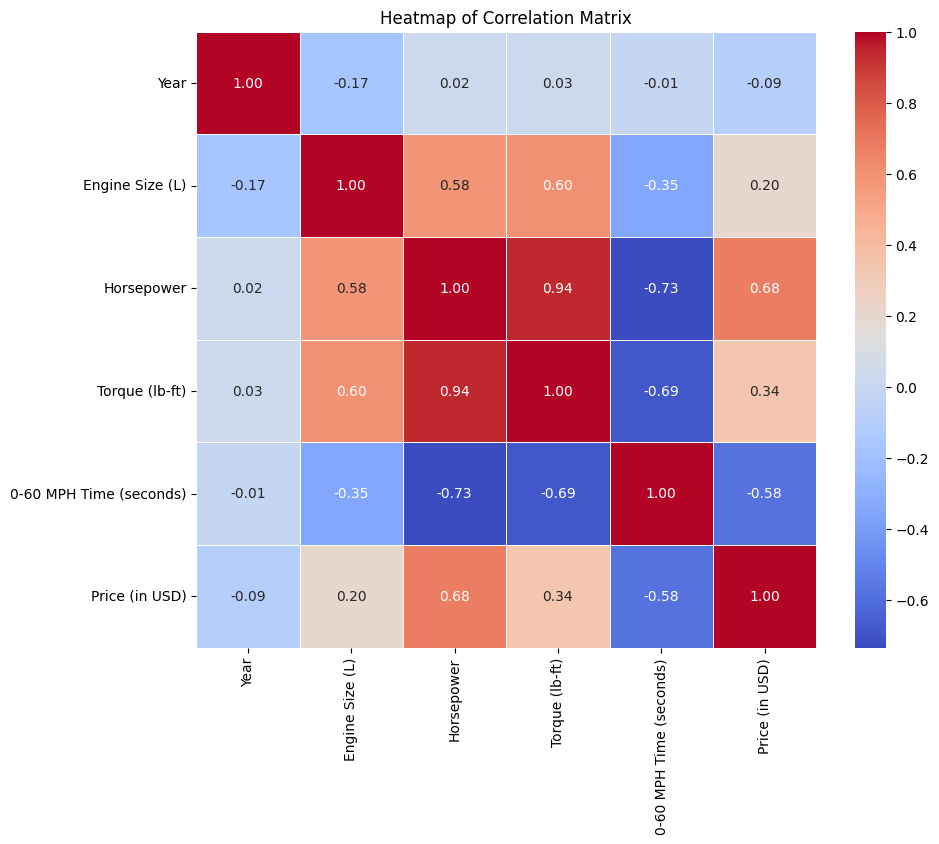

In [39]:
import matplotlib.pyplot as plt   
import seaborn as sns

df['Engine Size (L)']=pd.to_numeric(df['Engine Size (L)'], errors='coerce')
df['Horsepower']=pd.to_numeric(df['Horsepower'],errors="coerce")
df['Torque (lb-ft)']=pd.to_numeric(df['Torque (lb-ft)'],errors="coerce")
df['0-60 MPH Time (seconds)']=pd.to_numeric(df['0-60 MPH Time (seconds)'],errors="coerce")
df['Price (in USD)']=pd.to_numeric(df['Price (in USD)'],errors="coerce")
df=df.drop(columns=["Car Make","Car Model"])
print(df.head())
# Tính toán ma trận tương quan
correlation_matrix = df.corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))  # Điều chỉnh kích thước hình
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Hiển thị heatmap
plt.title("Heatmap of Correlation Matrix")
plt.show()

In [56]:
#datapreproccesing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# Impute missing values in target y
imputer_y = SimpleImputer(strategy='mean')
df['Price (in USD)'] = imputer_y.fit_transform(df[['Price (in USD)']]).ravel()
y=df["Price (in USD)"]
x=df.drop(columns="Price (in USD)")
x_train,x_val,y_train,y_val=train_test_split(x,y,train_size=0.8,test_size=0.2)

columns = list(x.columns)
transformer=SimpleImputer(strategy="mean")
scaler=StandardScaler()
preprocessor=ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", transformer), ("scaler", scaler)]), columns)
    ]
)
model=RandomForestRegressor(n_estimators=200,max_depth=int(num_col**0.5),random_state=1)

my_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',model)
])
print(x.isna().sum())
print(my_pipeline.steps)
my_pipeline.fit(x_train,y_train)
predictions=my_pipeline.predict(x_val)
print(mean_absolute_error(y_val,predictions))

Year                       0
Engine Size (L)            0
Horsepower                 0
Torque (lb-ft)             0
0-60 MPH Time (seconds)    0
dtype: int64
[('preprocessor', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Year', 'Engine Size (L)', 'Horsepower',
                                  'Torque (lb-ft)',
                                  '0-60 MPH Time (seconds)'])])), ('model', RandomForestRegressor(max_depth=2, n_estimators=200, random_state=1))]
49.92152516754687
